# 06 Model Tuning on Dev-Noisy (Noisy Offline MLP)

This notebook performs **model tuning** using only dev-noisy data.

Tuning targets in this notebook:
- model checkpoint selection (compare multiple trained checkpoints)
- decision threshold selection (choose threshold that maximizes dev F1)

No test-noisy data is used in this notebook.

### Step 1: Import libraries
This step imports plotting, metrics, tensor, and utility libraries used throughout validation and checkpoint comparison.

In [1]:
import json
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    )

### Step 2: Resolve project paths and runtime config
This step finds the repository root, adds Step 05 modules to Python path, and sets shared configuration such as data paths, device, checkpoint filters, and threshold grid.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists() and (candidate / 'data' / 'generated').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from current working directory.')

ROOT = find_project_root(Path.cwd())
SRC_05 = ROOT / 'src' / '05_baseline_training'
if str(SRC_05) not in sys.path:
    sys.path.insert(0, str(SRC_05))

from baseline_mlp import BaselineMLP
from offline_dataset import build_dataloader

DATA_ROOT = ROOT / 'data' / 'generated'
ARTIFACTS_DIR = ROOT / 'artifacts'
CHECKPOINT_DIR = ARTIFACTS_DIR / 'checkpoints'

BATCH_SIZE = 2048
NUM_WORKERS = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CHECKPOINT_SUFFIXES = {'.pt', '.pth', '.ckpt'}
CHECKPOINT_NAME_CONTAINS = 'noisy_mlp'
THRESHOLDS = np.linspace(0.05, 0.95, 19)
TOP_K_PLOTS = 10

print('Project root        :', ROOT)
print('Step 05 src         :', SRC_05)
print('Data root           :', DATA_ROOT)
print('Checkpoint directory:', CHECKPOINT_DIR)
print('Device              :', DEVICE)

Project root        : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Step 05 src         : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_baseline_training
Data root           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
Checkpoint directory: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/checkpoints
Device              : cuda


### Step 3: Define checkpoint/model helper functions
This step defines reusable helpers for loading checkpoint formats, inferring model shape, constructing the model safely, and collecting logits/labels from the dataloader.

In [3]:
def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def _infer_mlp_shape_from_state(state_dict):
    linear_layers = []
    for k, v in state_dict.items():
        if not (k.startswith('backbone.') and k.endswith('.weight')):
            continue
        if not hasattr(v, 'shape') or len(v.shape) != 2:
            continue
        parts = k.split('.')
        if len(parts) < 3 or not parts[1].isdigit():
            continue
        idx = int(parts[1])
        out_dim, in_dim = int(v.shape[0]), int(v.shape[1])
        linear_layers.append((idx, in_dim, out_dim))

    if not linear_layers:
        raise RuntimeError('Could not infer backbone layers from checkpoint state_dict.')

    linear_layers.sort(key=lambda t: t[0])
    input_dim = linear_layers[0][1]
    hidden_dims = tuple(layer[2] for layer in linear_layers)
    dropout = 0.1 if len(linear_layers) >= 2 and (linear_layers[1][0] - linear_layers[0][0] == 3) else 0.0
    return input_dim, hidden_dims, dropout


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> BaselineMLP:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    input_dim, hidden_dims, dropout = _infer_mlp_shape_from_state(state)
    model = BaselineMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def collect_logits_labels(loader, model, device):
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x).detach().cpu().numpy()
            labels = y.detach().cpu().numpy().astype(np.int64)
            logits_all.append(logits)
            labels_all.append(labels)

    if not logits_all:
        raise RuntimeError('No samples collected from loader.')

    return np.concatenate(logits_all), np.concatenate(labels_all)

### Step 4: Build dev dataloader and discover checkpoints
This step builds the dev-noisy dataloader and scans artifacts/checkpoints for candidate model files to evaluate.

In [4]:
loader = build_dataloader(
    generated_dir=DATA_ROOT / 'dev',
    split='dev',
    manifest_type="noisy",
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

ckpt_candidates = sorted(
    [
        p for p in CHECKPOINT_DIR.rglob('*')
        if p.is_file() and p.suffix in CHECKPOINT_SUFFIXES
    ]
)
if CHECKPOINT_NAME_CONTAINS:
    key = CHECKPOINT_NAME_CONTAINS.lower()
    ckpt_candidates = [p for p in ckpt_candidates if key in p.name.lower()]

print('Dataset size          :', len(loader.dataset))
print('Checkpoint candidates :', len(ckpt_candidates))
for p in ckpt_candidates[:20]:
    print(' -', p.name)

if not ckpt_candidates:
    raise FileNotFoundError(f'No checkpoint files found under: {CHECKPOINT_DIR}')

Dataset size          : 1088453
Checkpoint candidates : 12
 - noisy_mlp_lr0.0003_wd0_dr0.0_seed42.pt
 - noisy_mlp_lr0.0003_wd0_dr0.1_seed42.pt
 - noisy_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt
 - noisy_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt
 - noisy_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt
 - noisy_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt
 - noisy_mlp_lr0.001_wd0_dr0.0_seed42.pt
 - noisy_mlp_lr0.001_wd0_dr0.1_seed42.pt
 - noisy_mlp_lr0.001_wd1e-4_dr0.0_seed42.pt
 - noisy_mlp_lr0.001_wd1e-4_dr0.1_seed42.pt
 - noisy_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt
 - noisy_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt


### Step 5: Evaluate all checkpoints and tune threshold per checkpoint
This step runs inference for each checkpoint on dev-noisy, performs threshold sweep, records best metrics for each model, and selects the top checkpoint by best dev F1.

In [5]:
def metrics_at_threshold(probs, labels, thr=0.5):
    pred = (probs >= thr).astype(np.int64)
    y = labels.astype(np.int64)

    tp = int(np.sum((pred == 1) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))

    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))

    # FAR: false alarms among actual non-speech frames
    far = fp / max(1, fp + tn)
    # Miss rate: missed speech among actual speech frames
    miss_rate = fn / max(1, fn + tp)

    return {
        'threshold': float(thr),
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'far': float(far),
        'miss_rate': float(miss_rate),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


results = []
failures = []

best_model = None
all_logits = None
all_labels = None
probs = None

for i, ckpt in enumerate(ckpt_candidates, start=1):
    try:
        model = load_model_from_checkpoint(ckpt, DEVICE)
        logits_i, labels_i = collect_logits_labels(loader, model, DEVICE)
        probs_i = 1.0 / (1.0 + np.exp(-logits_i))

        sweep_i = [metrics_at_threshold(probs_i, labels_i, thr=float(t)) for t in THRESHOLDS]
        best_idx = int(np.argmax([m['f1'] for m in sweep_i]))
        best_point = sweep_i[best_idx]

        result = {
            'checkpoint': str(ckpt),
            'checkpoint_name': ckpt.name,
            'best_threshold': best_point['threshold'],
            'accuracy': best_point['accuracy'],
            'precision': best_point['precision'],
            'recall': best_point['recall'],
            'f1': best_point['f1'],
            'far': best_point['far'],
            'miss_rate': best_point['miss_rate'],
            'tp': best_point['tp'],
            'tn': best_point['tn'],
            'fp': best_point['fp'],
            'fn': best_point['fn'],
            'sweep': sweep_i,
        }
        results.append(result)

        if best_model is None or result['f1'] > best_model['f1']:
            best_model = result
            all_logits = logits_i
            all_labels = labels_i
            probs = probs_i

        print(
            f"[{i:02d}/{len(ckpt_candidates)}] OK  {ckpt.name} | "
            f"F1={result['f1']:.6f}, P={result['precision']:.4f}, R={result['recall']:.4f}, "
            f"FAR={result['far']:.4f}, Miss={result['miss_rate']:.4f} @thr={result['best_threshold']:.2f}"
        )
    except Exception as e:
        failures.append((str(ckpt), repr(e)))
        print(f"[{i:02d}/{len(ckpt_candidates)}] FAIL {ckpt.name} | {e}")

if not results:
    raise RuntimeError('No checkpoint evaluated successfully.')

ranked = sorted(results, key=lambda r: r['f1'], reverse=True)
best_model = ranked[0]
best_threshold = float(best_model['best_threshold'])
preds = (probs >= best_threshold).astype(int)

print('\nBest checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print(
    "Best metrics   : "
    f"F1={best_model['f1']:.6f}, "
    f"Precision={best_model['precision']:.6f}, "
    f"Recall={best_model['recall']:.6f}, "
    f"FAR={best_model['far']:.6f}, "
    f"MissRate={best_model['miss_rate']:.6f}"
)
print('Failures       :', len(failures))

[01/12] OK  noisy_mlp_lr0.0003_wd0_dr0.0_seed42.pt | F1=0.873519, P=0.8442, R=0.9049, FAR=0.3749, Miss=0.0951 @thr=0.45
[02/12] OK  noisy_mlp_lr0.0003_wd0_dr0.1_seed42.pt | F1=0.872534, P=0.8406, R=0.9070, FAR=0.3863, Miss=0.0930 @thr=0.45
[03/12] OK  noisy_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt | F1=0.873633, P=0.8449, R=0.9044, FAR=0.3729, Miss=0.0956 @thr=0.45
[04/12] OK  noisy_mlp_lr0.0003_wd1e-4_dr0.1_seed42.pt | F1=0.872451, P=0.8389, R=0.9087, FAR=0.3917, Miss=0.0913 @thr=0.45
[05/12] OK  noisy_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt | F1=0.873532, P=0.8453, R=0.9037, FAR=0.3714, Miss=0.0963 @thr=0.45
[06/12] OK  noisy_mlp_lr0.0003_wd1e-5_dr0.1_seed42.pt | F1=0.872730, P=0.8400, R=0.9081, FAR=0.3883, Miss=0.0919 @thr=0.45
[07/12] OK  noisy_mlp_lr0.001_wd0_dr0.0_seed42.pt | F1=0.874073, P=0.8511, R=0.8984, FAR=0.3530, Miss=0.1016 @thr=0.45
[08/12] OK  noisy_mlp_lr0.001_wd0_dr0.1_seed42.pt | F1=0.873133, P=0.8425, R=0.9061, FAR=0.3804, Miss=0.0939 @thr=0.45
[09/12] OK  noisy_mlp_lr0.001_

**Output explanation**

The evaluation on the dev-noisy dataset shows that the best-performing model achieves an F1 score of 0.874 with a learning rate of 0.001, weight decay of 1e-5, and no dropout, using a threshold of 0.45. The results across different checkpoints are very close, indicating that the model is stable and not highly sensitive to hyperparameter changes such as learning rate, weight decay, or dropout. This suggests that the training setup is robust. Additionally, a threshold around 0.45 provides a good balance between precision and recall, maintaining relatively low false alarm and miss rates.

### Step 6: Print checkpoint leaderboard
This step prints a ranked table of all successfully evaluated checkpoints, including each model's best threshold and metrics.

In [6]:
print('Top checkpoints by dev F1:')
print('-' * 132)
print(f"{'rank':>4s}  {'checkpoint':<55s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}  {'far':>9s}  {'miss':>9s}")
print('-' * 132)

for idx, r in enumerate(ranked, start=1):
    print(
        f"{idx:>4d}  {r['checkpoint_name']:<55.55s}  {r['best_threshold']:>5.2f}  "
        f"{r['f1']:>9.6f}  {r['accuracy']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}  "
        f"{r['far']:>9.6f}  {r['miss_rate']:>9.6f}"
    )

if failures:
    print('\nFailed checkpoints:')
    for ckpt, err in failures:
        print(' -', Path(ckpt).name, '|', err)

Top checkpoints by dev F1:
------------------------------------------------------------------------------------------------------------------------------------
rank  checkpoint                                                 thr         f1        acc       prec        rec        far       miss
------------------------------------------------------------------------------------------------------------------------------------
   1  noisy_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt                  0.45   0.874380   0.821414   0.851686   0.898317   0.351265   0.101683
   2  noisy_mlp_lr0.001_wd0_dr0.0_seed42.pt                     0.45   0.874073   0.820908   0.851072   0.898351   0.352986   0.101649
   3  noisy_mlp_lr0.0003_wd1e-4_dr0.0_seed42.pt                 0.45   0.873633   0.818973   0.844857   0.904437   0.372930   0.095563
   4  noisy_mlp_lr0.0003_wd1e-5_dr0.0_seed42.pt                 0.45   0.873532   0.818949   0.845283   0.903735   0.371431   0.096265
   5  noisy_mlp_lr0.0003_wd0_dr0

**Output explanation**

The dev-noisy evaluation shows that the top-performing model achieves an F1 score of 0.874 with a learning rate of 0.001, weight decay of 1e-5, and no dropout at a threshold of 0.45. The top several models have nearly identical performance, with F1 differences within 0.001, indicating that the model is highly stable and not very sensitive to hyperparameter variations. Models without dropout consistently perform slightly better, suggesting that regularization through dropout is not necessary for this task. A threshold of 0.45 appears optimal for most configurations, providing a good balance between precision and recall while keeping false alarm rate and miss rate relatively low. Lowering the threshold to 0.40 increases recall but also significantly increases the false alarm rate, leading to a slight drop in overall F1 score.

### Step 7: Compare metrics across top checkpoints
This step visualizes accuracy, precision, recall, and F1 across top models so performance differences are easy to compare side by side.

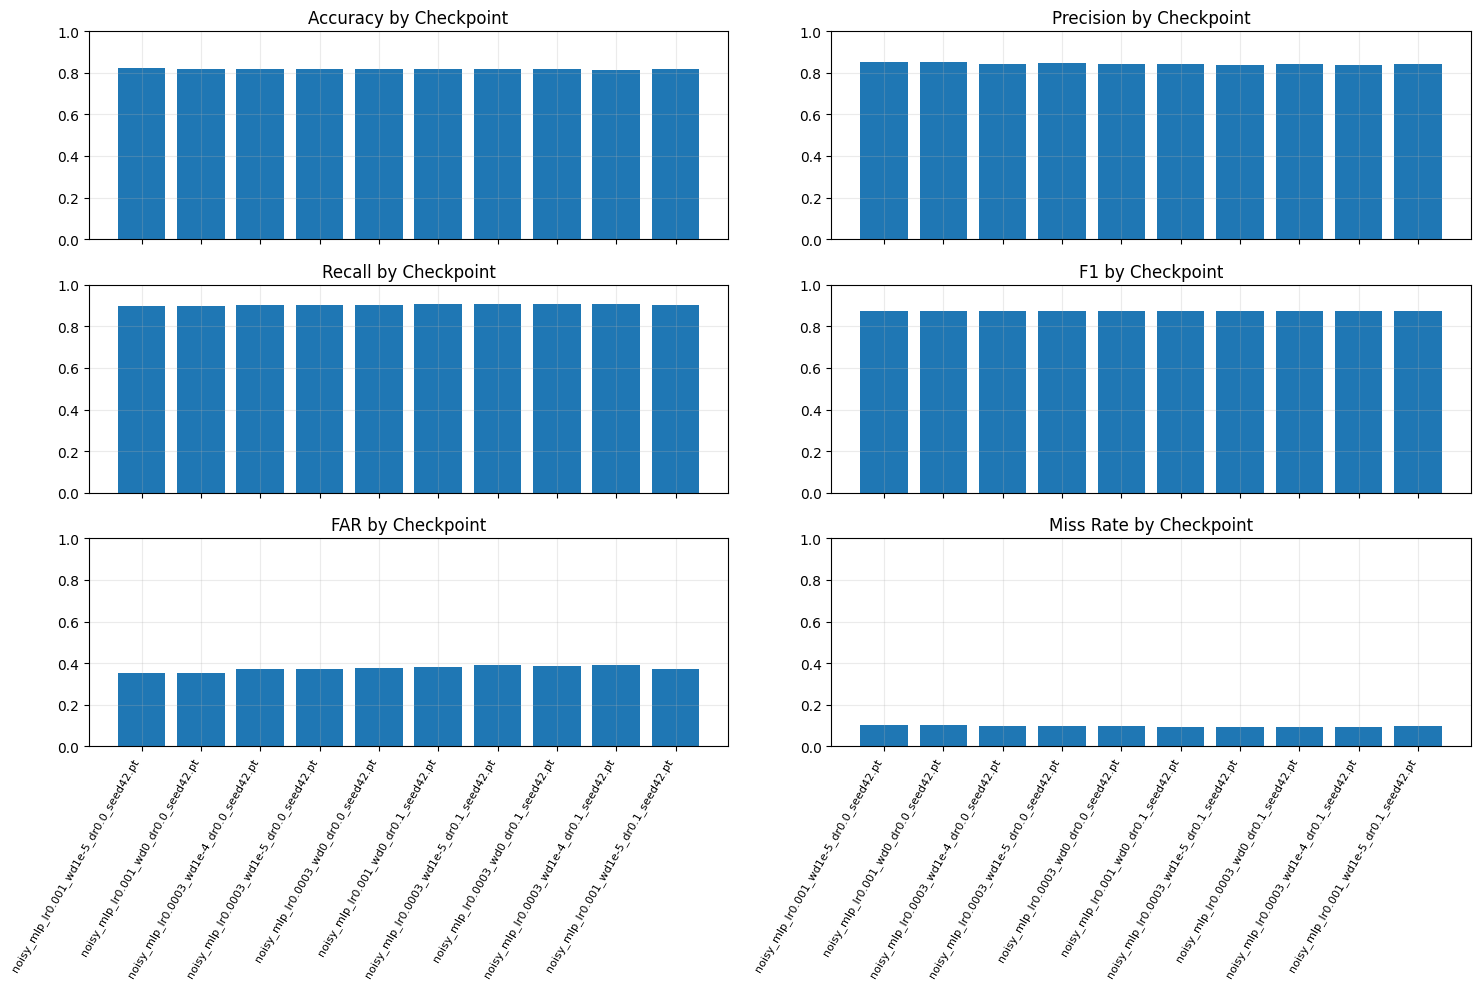

Best checkpoint: noisy_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt
Best threshold : 0.45
Best metrics   : acc=0.821414,  prec=0.851686,  rec=0.898317,  f1=0.874380,  far=0.351265,  miss=0.101683


In [13]:
top = ranked[: min(TOP_K_PLOTS, len(ranked))]
names = [r['checkpoint_name'] for r in top]
x = np.arange(len(top))

acc_vals = [r['accuracy'] for r in top]
prec_vals = [r['precision'] for r in top]
rec_vals = [r['recall'] for r in top]
f1_vals = [r['f1'] for r in top]
far_vals = [r['far'] for r in top]
miss_vals = [r['miss_rate'] for r in top]

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

axes[0].bar(x, acc_vals)
axes[0].set_title('Accuracy by Checkpoint')
axes[0].set_ylim(0, 1)

axes[1].bar(x, prec_vals)
axes[1].set_title('Precision by Checkpoint')
axes[1].set_ylim(0, 1)

axes[2].bar(x, rec_vals)
axes[2].set_title('Recall by Checkpoint')
axes[2].set_ylim(0, 1)

axes[3].bar(x, f1_vals)
axes[3].set_title('F1 by Checkpoint')
axes[3].set_ylim(0, 1)

axes[4].bar(x, far_vals)
axes[4].set_title('FAR by Checkpoint')
axes[4].set_ylim(0, 1)

axes[5].bar(x, miss_vals)
axes[5].set_title('Miss Rate by Checkpoint')
axes[5].set_ylim(0, 1)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Best checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print('Best metrics   :',
      f"acc={best_model['accuracy']:.6f}, ",
      f"prec={best_model['precision']:.6f}, ",
      f"rec={best_model['recall']:.6f}, ",
      f"f1={best_model['f1']:.6f}, ",
      f"far={best_model['far']:.6f}, ",
      f"miss={best_model['miss_rate']:.6f}")

**Output explanation**

The results across all checkpoints are very consistent, as seen in the plots where accuracy, precision, recall, and F1 scores vary only slightly between models. The best model achieves an F1 score of 0.874, but the differences among the top models are minimal, indicating stable training and low sensitivity to hyperparameters. Models without dropout tend to perform slightly better, suggesting that additional regularization is not necessary for this task. The FAR and miss rate plots show a clear trade-off: models with higher recall generally have higher FAR, while lower miss rates come at the cost of more false alarms. Overall, a threshold of 0.45 provides a good balance between precision and recall, leading to strong and consistent performance across all metrics.

### Step 8: Visualize confusion matrix for best checkpoint
This step plots the confusion matrix of the selected best model using its tuned decision threshold.

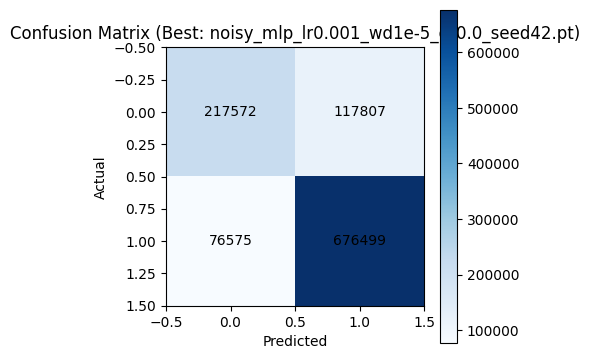

In [8]:
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(4.5, 4.0))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (Best: {best_model['checkpoint_name']})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

**Output explanation**

The confusion matrix shows that the model correctly identifies a large number of both non-speech (217,572) and speech frames (676,499). However, there are still notable misclassifications, with 117,807 false positives and 76,575 false negatives. The higher number of false positives compared to false negatives indicates that the model tends to predict speech more often, which aligns with its relatively high recall. Overall, the model captures most speech frames effectively but at the cost of introducing some extra false alarms.

### Step 9: Plot ROC curve for best checkpoint
This step computes and visualizes the ROC curve and AUC for the selected best model on dev-noisy.

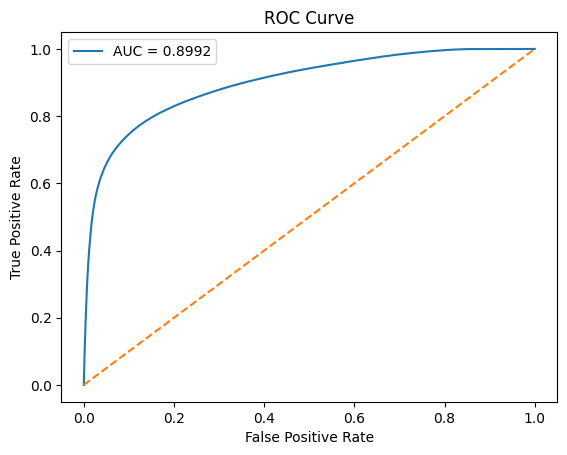

In [9]:
fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Output explanation**

The ROC curve shows strong discriminative performance, with an AUC of approximately 0.899. The curve rises steeply at low false positive rates, indicating that the model can capture a large portion of true speech frames with relatively few false alarms. Overall, the model demonstrates good separation between speech and non-speech, though it is not perfect, as reflected by the gradual flattening of the curve at higher false positive rates.

### Step 10: Plot precision-recall curve for best checkpoint
This step visualizes the precision-recall trade-off, which is often informative for imbalanced frame-level classification tasks.

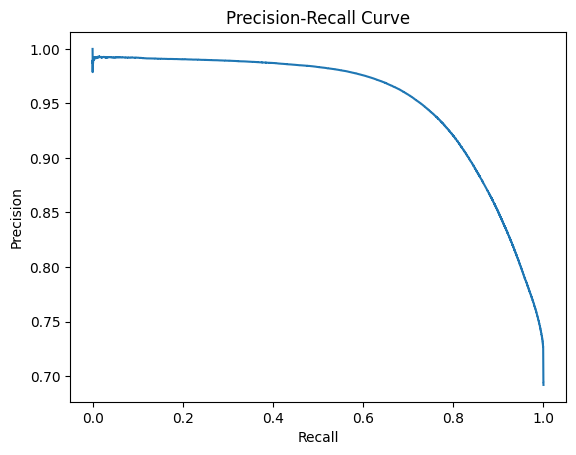

In [10]:
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Output explanation**

The precision–recall curve shows a clear trade-off between precision and recall. Precision remains very high (close to 1.0) at lower recall levels, indicating confident predictions when the model is more conservative. As recall increases, precision gradually decreases, dropping more sharply at higher recall values. This pattern suggests that capturing more speech frames comes at the cost of increasing false positives. Overall, the curve indicates strong performance, with the model maintaining high precision across a wide range of recall before declining near full recall.

### Step 11: Visualize F1 versus threshold
This step plots the F1-threshold curve for the best checkpoint to make threshold behavior easy to inspect.

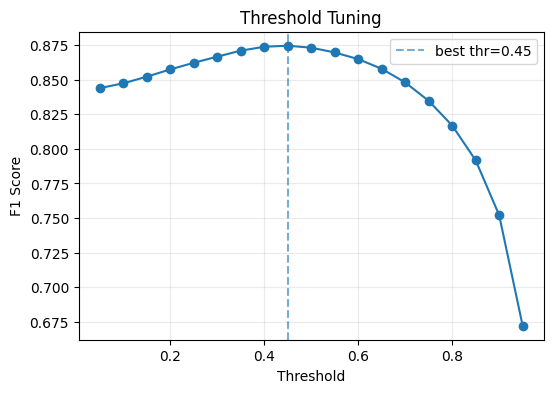

Best threshold from curve: 0.45
Best F1 from curve       : 0.874380


In [11]:
thresholds = THRESHOLDS
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(np.int64)
    f1_scores.append(f1_score(all_labels, preds_t))

best_idx = int(np.argmax(f1_scores))
best_thr_curve = float(thresholds[best_idx])
best_f1_curve = float(f1_scores[best_idx])

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_thr_curve, linestyle='--', alpha=0.6, label=f'best thr={best_thr_curve:.2f}')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Tuning")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Best threshold from curve: {best_thr_curve:.2f}")
print(f"Best F1 from curve       : {best_f1_curve:.6f}")

**Output explanation**

The threshold tuning curve shows that F1 score increases as the threshold rises, reaching a peak around 0.45, and then gradually declines. At very low thresholds, the model predicts too many positives, lowering precision, while at high thresholds, it becomes too conservative, reducing recall. The optimal threshold around 0.45 provides the best balance between precision and recall, resulting in the highest F1 score.

### Step 13: Export evaluation artifacts and tuned configuration
This step saves prediction arrays, the checkpoint leaderboard, and the final tuned config for reproducible downstream testing/reporting.

In [15]:
eval_dir = ARTIFACTS_DIR / 'eval_outputs_noisy_mlp'
eval_dir.mkdir(parents=True, exist_ok=True)

np.save(eval_dir / 'eval_logits.npy', all_logits)
np.save(eval_dir / 'eval_probs.npy', probs)
np.save(eval_dir / 'eval_labels.npy', all_labels)

with open(eval_dir / 'checkpoint_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(
        [
            {
                'checkpoint': r['checkpoint'],
                'checkpoint_name': r['checkpoint_name'],
                'best_threshold': r['best_threshold'],
                'accuracy': r['accuracy'],
                'precision': r['precision'],
                'recall': r['recall'],
                'f1': r['f1'],
                'far': r['far'],
                'miss_rate': r['miss_rate'],
                'tp': r['tp'],
                'tn': r['tn'],
                'fp': r['fp'],
                'fn': r['fn'],
            }
            for r in ranked
        ],
        f,
        indent=2,
    )

noisy_config_path = ARTIFACTS_DIR / 'final_tuned_config_noisy_mlp.json'
with open(noisy_config_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint': best_model['checkpoint'],
            'threshold': best_threshold,
            'dev_metrics': {
                'accuracy': best_model['accuracy'],
                'precision': best_model['precision'],
                'recall': best_model['recall'],
                'f1': best_model['f1'],
                'far': best_model['far'],
                'miss_rate': best_model['miss_rate'],
                'tp': best_model['tp'],
                'tn': best_model['tn'],
                'fp': best_model['fp'],
                'fn': best_model['fn'],
            },
        },
        f,
        indent=2,
    )

print('Saved evaluation arrays to:', eval_dir)
print('Saved leaderboard to     :', eval_dir / 'checkpoint_leaderboard.json')
print('Saved tuned config to    :', noisy_config_path)

Saved evaluation arrays to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_noisy_mlp
Saved leaderboard to     : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_noisy_mlp/checkpoint_leaderboard.json
Saved tuned config to    : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/final_tuned_config_noisy_mlp.json
